In [3]:
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, brier_score_loss
)
from sklearn.utils.class_weight import compute_class_weight

In [2]:
# Load balanced training and test sets
X_train_res, y_train_res = joblib.load("X_train_balanced.pkl")
X_test, y_test           = joblib.load("X_test_balanced.pkl")
class_names              = joblib.load("class_names.pkl")

Train SVM with Class Weights

In [3]:
# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_res), y=y_train_res)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

# Train calibrated SVM
svm_model = CalibratedClassifierCV(
    SVC(C=50, gamma=0.001, kernel='rbf',
        class_weight=class_weight_dict, probability=True, random_state=42),
    method='isotonic', cv=3
)
svm_model.fit(X_train_res, y_train_res)

# Save model
joblib.dump(svm_model, "svm.pkl")
print("✅ SVM model trained and saved as svm.pkl")

✅ SVM model trained and saved as svm.pkl


In [5]:
#Confusion Matrix

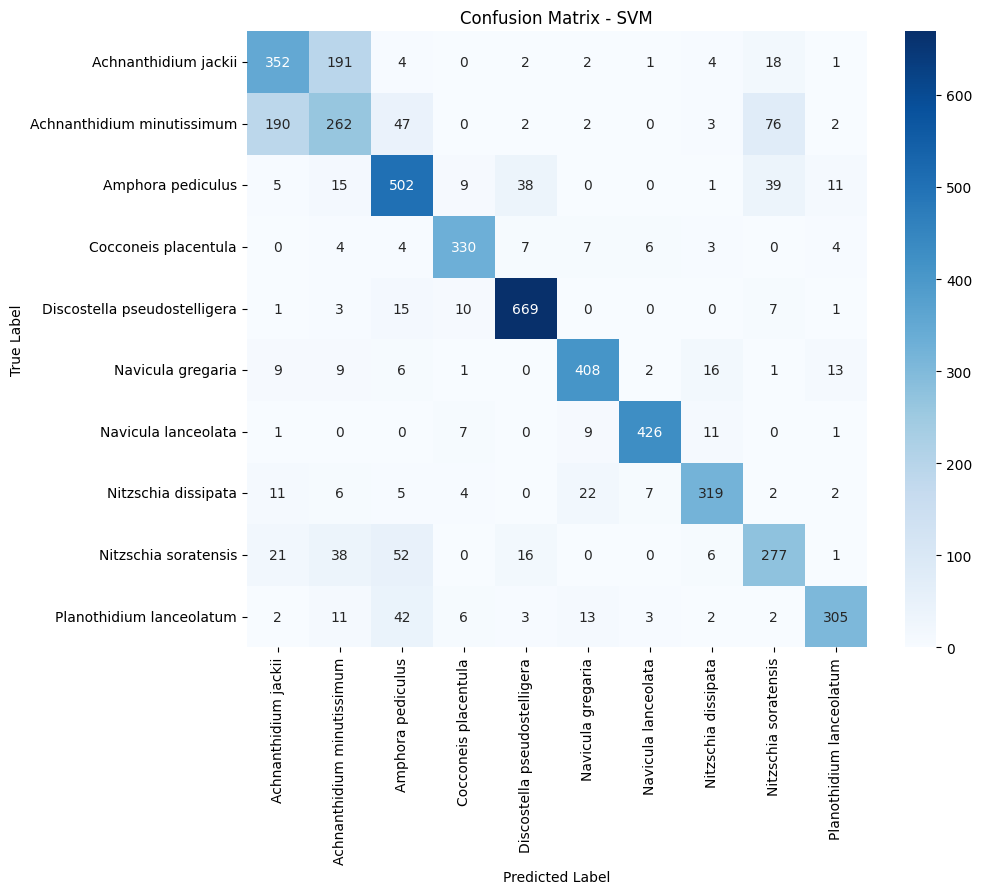

In [4]:
svm_model   = joblib.load("svm.pkl")
X_test, y_test = joblib.load("X_test_balanced.pkl")
class_names = joblib.load("class_names.pkl")

# Predict
y_pred = svm_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM")
plt.show()


Significance:
Confusion matrix shows how well the model distinguishes between species, highlighting misclassifications


ROC Curve

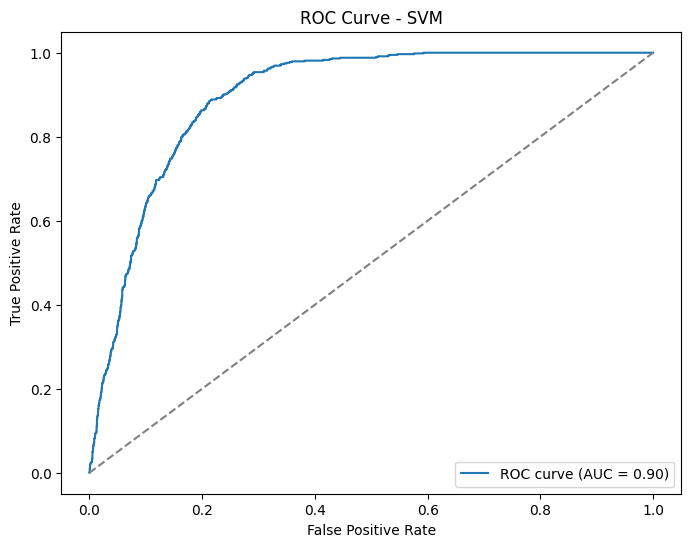

In [5]:
y_prob = svm_model.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_prob[:,1], pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

Significance:
ROC curve visualizes trade-off between sensitivity and specificity. AUC quantifies overall performance.


Precision-Recall Curve

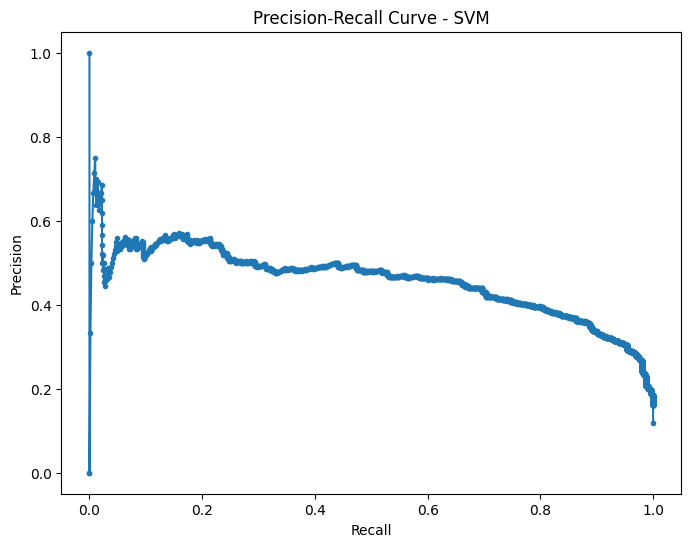

In [6]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob[:,1], pos_label=1)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM")
plt.show()

Significance:
PR curve is especially useful for imbalanced datasets, showing how precision varies with recall.


 Confidence Frequency Distributio

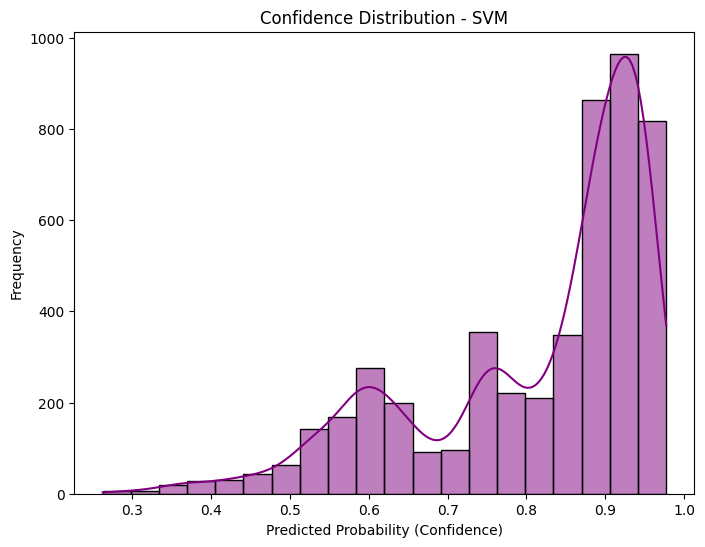

In [7]:
plt.figure(figsize=(8,6))
sns.histplot(np.max(y_prob, axis=1), bins=20, kde=True, color="purple")
plt.xlabel("Predicted Probability (Confidence)")
plt.ylabel("Frequency")
plt.title("Confidence Distribution - SVM")
plt.show()

Significance:
Shows how confident the model is in its predictions. Sharp peaks near 1.0 indicate strong confidence


Class-wise Accuracy

C:\Users\Yaswanth\AppData\Local\Temp\ipykernel_22392\951607060.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_acc, palette="viridis")


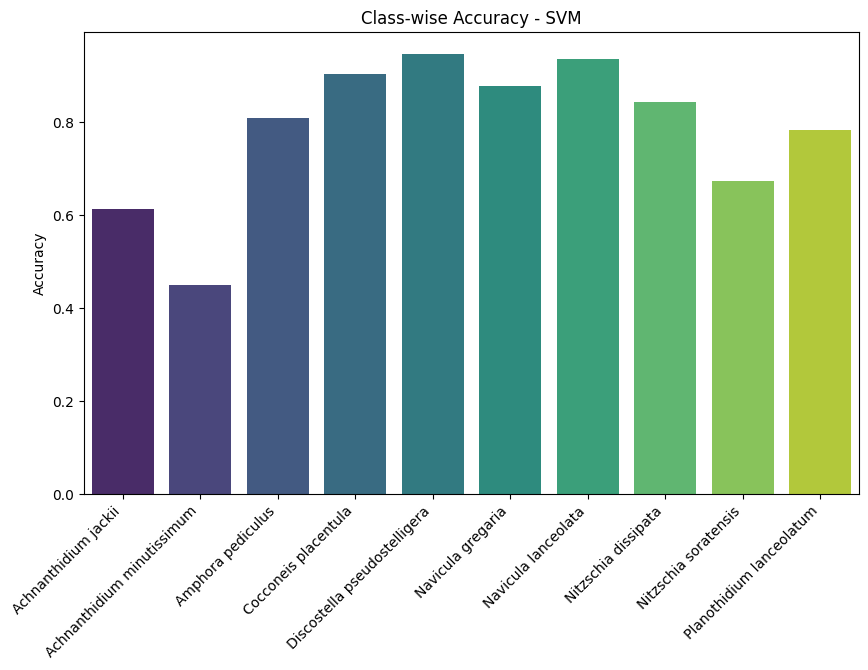

In [8]:
report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
class_acc = [report[cls]['recall'] for cls in class_names]

plt.figure(figsize=(10,6))
sns.barplot(x=class_names, y=class_acc, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Class-wise Accuracy - SVM")
plt.show()

Significance:
Shows per-class accuracy (recall), helping identify which species are harder to classify.


Reliability Plot (Calibration Curve)

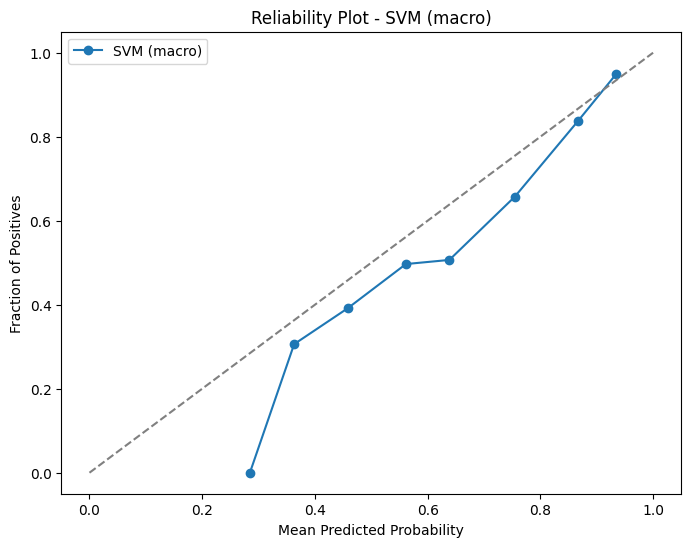

In [10]:
from sklearn.calibration import calibration_curve

# True if prediction was correct
y_pred = svm_model.predict(X_test)
correct = (y_pred == y_test).astype(int)

# Confidence = max predicted probability
confidence = np.max(y_prob, axis=1)

prob_true, prob_pred = calibration_curve(correct, confidence, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label="SVM (macro)")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Reliability Plot - SVM (macro)")
plt.legend()
plt.show()

Significance:
Reliability plot shows how well predicted probabilities match actual outcomes. A well-calibrated model lies close to the diagonal.


In [11]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on test set
y_pred = svm_model.predict(X_test)   # replace svm_model with lr_model, rf_model, etc.

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

Model Accuracy: 0.7781

Classification Report:
                              precision    recall  f1-score   support

        Achnanthidium jackii       0.59      0.61      0.60       575
  Achnanthidium minutissimum       0.49      0.45      0.47       584
           Amphora pediculus       0.74      0.81      0.77       620
        Cocconeis placentula       0.90      0.90      0.90       365
Discostella pseudostelligera       0.91      0.95      0.93       706
           Navicula gregaria       0.88      0.88      0.88       465
         Navicula lanceolata       0.96      0.94      0.95       455
         Nitzschia dissipata       0.87      0.84      0.86       378
        Nitzschia soratensis       0.66      0.67      0.67       411
    Planothidium lanceolatum       0.89      0.78      0.84       389

                    accuracy                           0.78      4948
                   macro avg       0.79      0.78      0.79      4948
                weighted avg       0.78  

✅ Workflow Summary
- Balanced dataset (ADASYN/SMOTE) ensures fair training.
- SVM model trained with isotonic calibration for reliable probabilities.
- Evaluation suite: confusion matrix, ROC, PR curve, confidence distribution, class-wise accuracy, reliability plot.
- Model saved as svm.pkl for reuse.
